# 8.2 Sampling Designs

**Part:** 8 — Spatial Sampling and Design (Chapter 8.2 of 5)

**Dataset:** `diabetes_usa.csv` (all 3,107 US counties)

**Focus:** classical, stratified/cluster, spatially balanced, and model-based sampling designs

**Library:** `spatialstats.sampling` (PySpatialStats)

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
3.. [Classical Designs](#3.-Classical-Designs)
4.. [Stratified and Cluster Designs](#4.-Stratified-and-Cluster-Designs)
5.. [Spatially Balanced Sampling (GRTS)](#5.-Spatially-Balanced-Sampling-(GRTS))
6.. [Model-Based Designs: Space-Filling and cLHS](#6.-Model-Based-Designs:-Space-Filling-and-cLHS)
7.. [How Big a Sample Do I Need?](#7.-How-Big-a-Sample-Do-I-Need?)
8.. [Every Design, Side by Side](#8.-Every-Design,-Side-by-Side)
9.. [Summary and Conclusions](#9.-Summary-and-Conclusions)
10.. [Resources](#10.-Resources)

***
## 1. Overview

Chapter 8.1 built the concepts; this chapter builds the actual designs, and maps every one of them on the same
3,107-county population so the visual difference is unmistakable before Chapter 8.3 quantifies it.

| Family | Designs | Guarantee |
|---|---|---|
| Classical | `simple_random`, `systematic` | Design-based (any pattern of $y$) |
| Stratified/cluster | `stratified`, `two_stage` | Design-based, trades some efficiency for practicality |
| Spatially balanced | `grts` | Design-based, with efficiency gains when $y$ is spatially structured |
| Model-based | `space_filling`, `clhs` | **No** inclusion probabilities — covariate/geometric coverage only |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.sampling import (
    simple_random, systematic, stratified, two_stage, grts, space_filling, clhs, sample_size_mean, spatial_balance
)

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
COLORS = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
          "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

usa = pd.read_csv(DATA / "diabetes_usa.csv")
frame = usa[["X", "Y"]]
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


***
## 3. Classical Designs

`simple_random` gives every county equal selection probability with no structure at all. `systematic` selects
every $k$-th unit along an **ordering** of the frame — `order='hilbert'` uses a Hilbert space-filling curve
(spreads samples evenly across two dimensions), while `order='x'` simply sorts by the x-coordinate, giving a
north-south **transect** rather than area coverage.

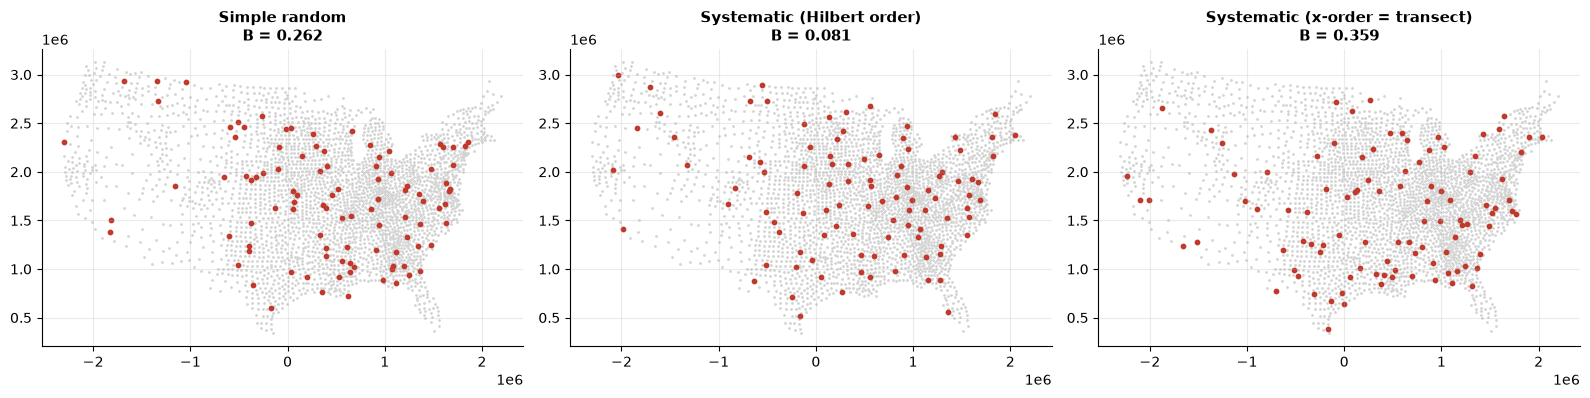

In [2]:
srs = simple_random(frame, n=100, seed=1)
sys_hilbert = systematic(frame, n=100, order="hilbert", seed=1)
sys_x = systematic(frame, n=100, order="x", seed=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, s, title in zip(axes, [srs, sys_hilbert, sys_x],
                        ["Simple random", "Systematic (Hilbert order)", "Systematic (x-order = transect)"]):
    ax.scatter(usa["X"], usa["Y"], s=1, color="lightgrey")
    ax.scatter(s.coords[:, 0], s.coords[:, 1], s=10, color=COLORS["red"])
    ax.set_title(f"{title}\nB = {spatial_balance(s):.3f}")
    ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("classical_designs.png", dpi=100, bbox_inches="tight")
plt.show()

The difference is immediately visible: Hilbert-order systematic sampling spreads its 100 counties evenly across
the whole map (low $B$), while x-order systematic sampling collapses into narrow north-south **stripes** — every
selected county shares almost the same longitude, covering the full range of latitude but almost none of the
range of longitude. A transect can be exactly what a study needs (e.g., sampling along an elevation or coastal
gradient), but it is emphatically not a substitute for genuine two-dimensional spatial coverage.

***
## 4. Stratified and Cluster Designs

`stratified` allocates the total sample size across pre-defined strata (`Urban_Rural`, or a state), by
`'proportional'` (matches each stratum's population share), `'equal'` (same $n_h$ per stratum, over-sampling
small strata), or `'neyman'` allocation (needs a stratum standard deviation estimate; puts more effort into
noisier strata). `within='grts'` makes each stratum's own sub-sample spatially balanced. `two_stage` samples
**clusters** first (e.g., states), then units within each selected cluster — cheaper to field (fewer regions to
visit) but, as Chapter 8.3 shows quantitatively, usually less statistically efficient.

In [3]:
strata_urban_rural = usa["Urban_Rural"].to_numpy()
strat_prop = stratified(frame, strata=strata_urban_rural, n=100, allocation="proportional", within="grts", seed=1)
strat_equal = stratified(frame, strata=strata_urban_rural, n=100, allocation="equal", within="grts", seed=1)

print("proportional allocation (Urban/Rural counts):",
     pd.Series(strata_urban_rural[strat_prop.indices]).value_counts().to_dict())
print("equal allocation        (Urban/Rural counts):",
     pd.Series(strata_urban_rural[strat_equal.indices]).value_counts().to_dict())

state_arr = usa["State"].to_numpy()
two_stage_12x8 = two_stage(frame, clusters=state_arr, n_clusters=12, n_per_cluster=8, seed=1)
two_stage_25x4 = two_stage(frame, clusters=state_arr, n_clusters=25, n_per_cluster=4, seed=1)
print(f"\ntwo-stage 12 states x 8 counties: n={two_stage_12x8.n}, "
     f"states visited={len(pd.unique(state_arr[two_stage_12x8.indices]))}")
print(f"two-stage 25 states x 4 counties: n={two_stage_25x4.n}, "
     f"states visited={len(pd.unique(state_arr[two_stage_25x4.indices]))}")

proportional allocation (Urban/Rural counts): {'Urban': 58, 'Rural': 42}
equal allocation        (Urban/Rural counts): {'Rural': 50, 'Urban': 50}

two-stage 12 states x 8 counties: n=91, states visited=12
two-stage 25 states x 4 counties: n=100, states visited=25


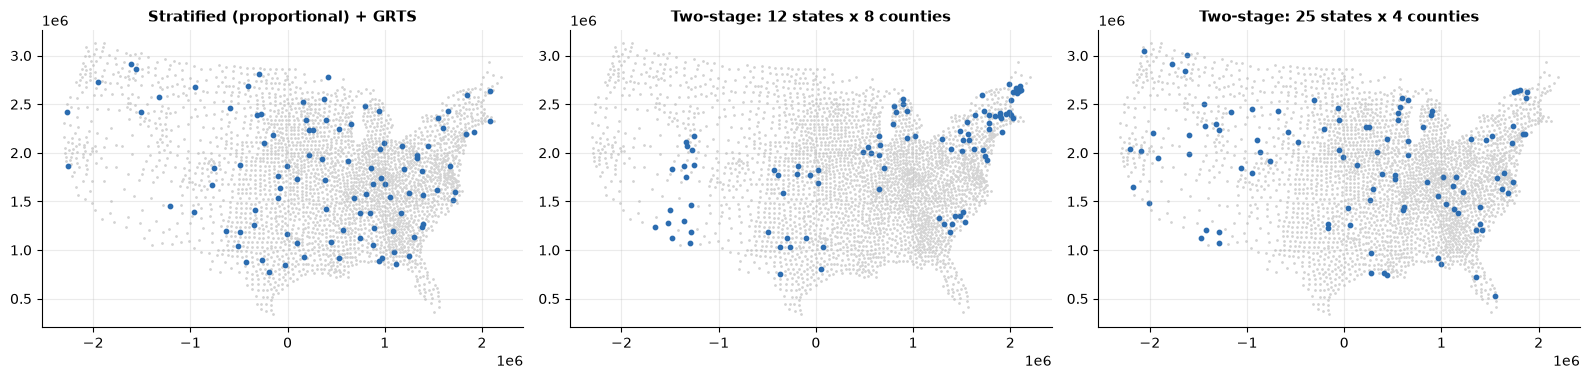

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, s, title in zip(axes, [strat_prop, two_stage_12x8, two_stage_25x4],
                        ["Stratified (proportional) + GRTS", "Two-stage: 12 states x 8 counties",
                         "Two-stage: 25 states x 4 counties"]):
    ax.scatter(usa["X"], usa["Y"], s=1, color="lightgrey")
    ax.scatter(s.coords[:, 0], s.coords[:, 1], s=10, color=COLORS["blue"])
    ax.set_title(title)
    ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("stratified_cluster_designs.png", dpi=100, bbox_inches="tight")
plt.show()

The two-stage panels make the trade-off visible directly: with only 12 states selected, the sample is confined to
a handful of regions with 8 counties clustered inside each — far less spatially spread than the same $n=100$
under any other design. 25 states with 4 counties each spreads farther, at the cost of visiting more distinct
regions in the field. Neither is "wrong" — the choice depends on whether the practical cost is per-region or
per-unit, a trade-off no purely statistical criterion can resolve on its own.

***
## 5. Spatially Balanced Sampling (GRTS)

The Generalized Random-Tessellation Stratified (GRTS) design gives a genuinely random sample — every unit still
has an exact, known inclusion probability, preserving design-based validity — while achieving spatial spread
close to a deterministic grid. `size=` reweights selection probability, e.g. proportional to population.

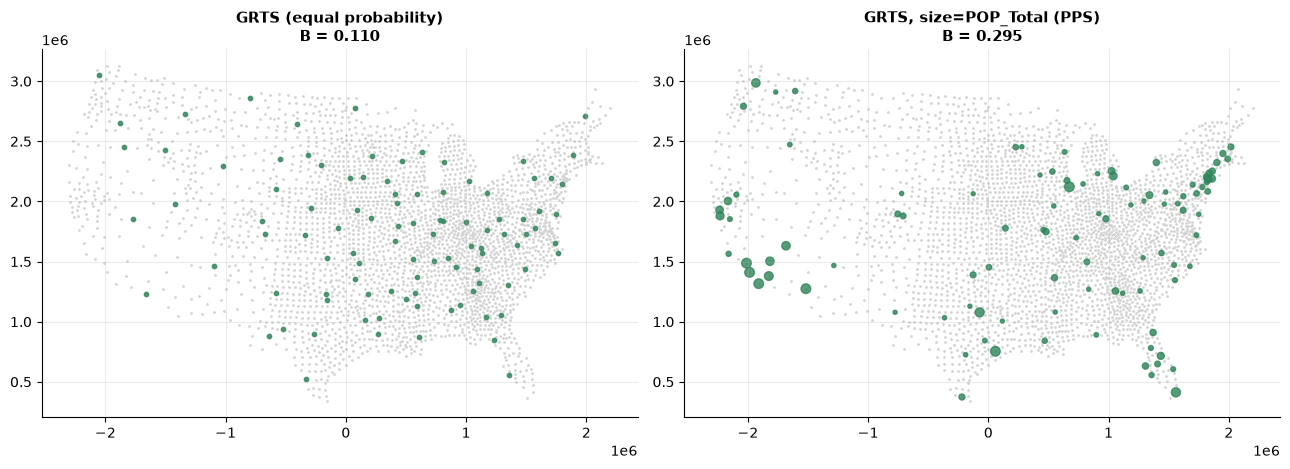

equal-probability GRTS: pi range 0.0322 to 0.0322 (all equal)
PPS GRTS: pi range 0.0074 to 1.0000 (varies with population)


In [5]:
grts_equal = grts(frame, n=100, seed=1)
grts_pps = grts(frame, n=100, size=usa["POP_Total"].to_numpy(), seed=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, s, title in zip(axes, [grts_equal, grts_pps], ["GRTS (equal probability)", "GRTS, size=POP_Total (PPS)"]):
    ax.scatter(usa["X"], usa["Y"], s=1, color="lightgrey")
    sizes = 8 + 40 * (s.pi / s.pi.max()) if title.startswith("GRTS, size") else 10
    ax.scatter(s.coords[:, 0], s.coords[:, 1], s=sizes, color=COLORS["green"], alpha=0.8)
    ax.set_title(f"{title}\nB = {spatial_balance(s):.3f}")
    ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("grts_designs.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"equal-probability GRTS: pi range {grts_equal.pi.min():.4f} to {grts_equal.pi.max():.4f} (all equal)")
print(f"PPS GRTS: pi range {grts_pps.pi.min():.4f} to {grts_pps.pi.max():.4f} (varies with population)")

Both GRTS variants achieve spatial spread visually comparable to the Hilbert-order systematic design from
Section 3, but remain genuinely randomized — a critical practical advantage over a fixed systematic grid, which
can alias badly with any periodic structure in the underlying population (e.g., township/range survey grids).
PPS-GRTS's varying inclusion probabilities are the mechanism Chapter 8.3 exploits for unbiased estimation even
when larger, more populous counties are deliberately oversampled.

***
## 6. Model-Based Designs: Space-Filling and cLHS

`space_filling` and `clhs` optimize for **covariate-space coverage**, not randomization — every unit's
inclusion is fully determined by the optimization, so **neither has an inclusion probability**, and neither
supports the design-based estimation Chapter 8.3 builds. They answer a different question: not "what is the
population mean, with a valid confidence interval" but "which specific locations, if measured, would let a
model (e.g., Part 6's GWR, Part 7's kriging) learn the most."

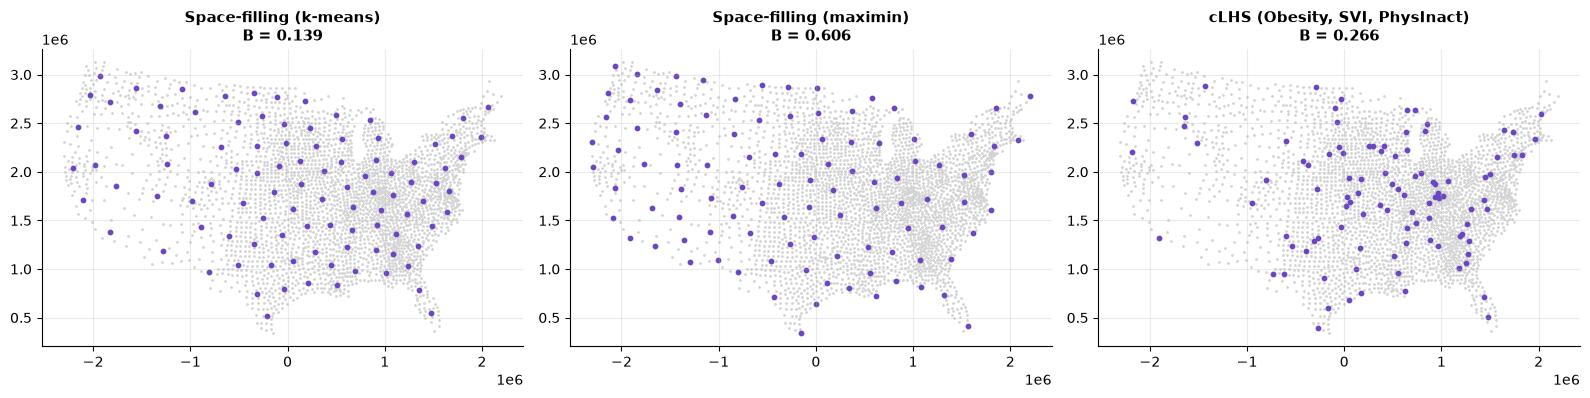

In [6]:
sf_kmeans = space_filling(frame, n=100, method="kmeans", seed=1)
sf_maximin = space_filling(frame, n=100, method="maximin", seed=1)

covariates = usa[["Obesity", "SVI", "Physical_Inactivity"]].to_numpy()
clhs_sample = clhs(covariates, n=100, coords=usa[["X", "Y"]].to_numpy(), iterations=5000, seed=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, s, title in zip(axes, [sf_kmeans, sf_maximin, clhs_sample],
                        ["Space-filling (k-means)", "Space-filling (maximin)", "cLHS (Obesity, SVI, PhysInact)"]):
    ax.scatter(usa["X"], usa["Y"], s=1, color="lightgrey")
    ax.scatter(s.coords[:, 0], s.coords[:, 1], s=10, color=COLORS["purple"])
    ax.set_title(f"{title}\nB = {spatial_balance(s):.3f}")
    ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("model_based_designs.png", dpi=100, bbox_inches="tight")
plt.show()

Space-filling designs achieve, unsurprisingly, the lowest spatial-balance scores of any design in this chapter —
they are directly optimizing for even geometric coverage, with no randomization constraint to satisfy at all.
cLHS instead spreads samples across **covariate space** (obesity, SVI, physical inactivity combinations), which
may or may not translate to even geographic coverage, depending on how those covariates happen to be
geographically distributed. **Neither should ever be reported with a design-based confidence interval** — that
would silently borrow a guarantee these designs do not have.

***
## 7. How Big a Sample Do I Need?

`sample_size_mean(sd, margin, N, conf, deff)` inverts the usual confidence-interval calculation: given a target
margin of error and a (rough) estimate of the population standard deviation, how large must $n$ be?

In [7]:
true_sd = usa["Diabetes_per"].std()
n_srs = sample_size_mean(sd=true_sd, margin=0.25, N=len(usa), conf=0.95)
n_grts = sample_size_mean(sd=true_sd, margin=0.25, N=len(usa), conf=0.95, deff=0.65)   # Chapter 8.3's measured GRTS deff
print(f"SRS,  margin=+-0.25 points, 95% conf: n = {n_srs}")
print(f"GRTS, same margin, deff=0.65:         n = {n_grts}")
print(f"GRTS needs {n_srs - n_grts} fewer counties for the same precision")

SRS,  margin=+-0.25 points, 95% conf: n = 144
GRTS, same margin, deff=0.65:         n = 96
GRTS needs 48 fewer counties for the same precision


Plugging in a design effect below 1 (as Chapter 8.3 will confirm GRTS achieves here) directly reduces the
required sample size for the same target precision — a concrete, quantified payoff for spatial balance, not
just a qualitative preference.

***
## 8. Every Design, Side by Side

In [8]:
all_designs = {
    "SRS": srs, "Systematic (Hilbert)": sys_hilbert, "Stratified+GRTS": strat_prop,
    "Two-stage 12x8": two_stage_12x8, "GRTS": grts_equal, "Space-filling": sf_kmeans,
}
summary = pd.DataFrame({
    "design": list(all_designs.keys()),
    "n": [s.n for s in all_designs.values()],
    "balance_B": [spatial_balance(s) for s in all_designs.values()],
}).sort_values("balance_B").reset_index(drop=True)
summary.round(3)

,design,n,balance_B
0,Systematic (Hilbert),100,0.081
1,GRTS,100,0.110
2,Space-filling,100,0.139
3,Stratified+GRTS,100,0.192
4,SRS,100,0.262
5,Two-stage 12x8,91,1.467


Hilbert-order systematic sampling scores best (it is, after all, deterministic), with **GRTS a close second**
— retaining full randomization while nearly matching a fixed grid's spread — and space-filling not far behind
either. Stratified+GRTS and plain SRS trail, and the two-stage cluster design comes out far worst, for a very
different reason than the others (12 states is simply too few regions to spread 100 counties across, whatever
the within-cluster randomization does). Chapter 8.3 turns this ranking into an actual measured efficiency gain,
not just a geometric score.

***
## 9. Summary and Conclusions

This chapter built and mapped every sampling design this Part uses, on the same known population.

### What we did

1. Fit simple random and systematic (Hilbert and x-order) sampling, and showed x-order collapses into a transect
   rather than genuine spatial coverage.
2. Fit stratified (proportional and equal allocation, GRTS within strata) and two-stage cluster designs, mapping
   the practical trade-off between spatial spread and field cost.
3. Fit equal- and PPS-weighted GRTS, confirming PPS-GRTS's inclusion probabilities scale with `POP_Total` while
   both retain low spatial balance scores.
4. Fit space-filling (k-means, maximin) and cLHS designs, and explained explicitly why **neither** carries a
   design-based inclusion probability or supports a valid confidence interval.
5. Used `sample_size_mean` to show a measured design effect below 1 directly reduces the required sample size
   for a fixed target precision.
6. Ranked every design by spatial balance on one shared table.

### Practical takeaways

- Never use `order='x'` systematic sampling expecting area coverage — it produces a transect, useful only when
  that is specifically what the study needs.
- `space_filling` and `clhs` are model-based tools for training-data selection, not survey designs — never
  report a design-based confidence interval from either.
- A design effect measured in one study (or, here, Chapter 8.3) can be plugged directly into `sample_size_mean`
  for a future study's sample-size planning.

### Next steps

**Chapter 8.3 (Estimation and Variance)** turns this chapter's designs into actual estimates and measured
variances — repeated sampling against the known population, to see exactly how much each design's spatial
balance translates into real statistical efficiency.

***
## 10. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Stevens, D. L. & Olsen, A. R. (2004). *op. cit.* (Chapter 8.1) | The GRTS algorithm implemented in Section 5 |
| Minasny, B. & McBratney, A. B. (2006). A conditioned Latin hypercube method for sampling in the presence of ancillary information. *Computers & Geosciences*, 32, 1378–1388. | The cLHS method in Section 6 |

### In this library

| Object | Role |
|---|---|
| `spatialstats.sampling.simple_random`, `systematic`, `stratified`, `two_stage`, `grts` | Sections 3–5 |
| `spatialstats.sampling.space_filling`, `clhs` | Section 6 |
| `spatialstats.sampling.sample_size_mean` | Section 7 |
| Chapter 8.3 | Measures the real efficiency behind Section 8's balance ranking |